# Sales forcast model

In [20]:
import pandas as pd 
import numpy as np

df =  pd.read_csv(r"C:\Users\FireFly\Desktop\potfolio2.0\Retail sales Analysis\data\cleaned.csv")
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format = "mixed")

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
      .reset_index()
)

C:\Users\FireFly\AppData\Local\Temp\ipykernel_22860\3611519726.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


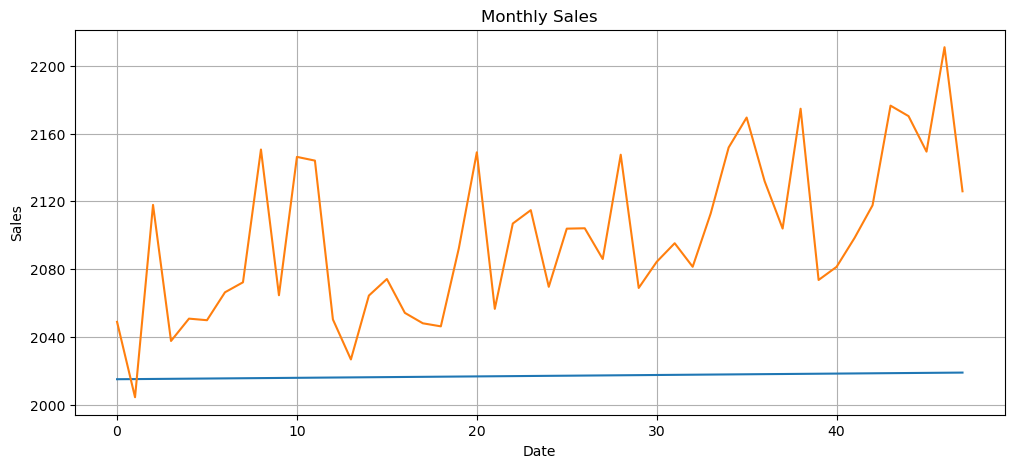

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [24]:
monthly_sales["Year"] = monthly_sales["Order Date"].dt.year
monthly_sales["Month"] = monthly_sales["Order Date"].dt.month
monthly_sales["Quarter"] = monthly_sales["Order Date"].dt.quarter

In [ ]:
monthly_sales["Lag1"] = monthly_sales["Sales"].shift(1)
monthly_sales["Lag2"] = monthly_sales["Sales"].shift(2)
monthly_sales["Lag3"] = monthly_sales["Sales"].shift(3)
monthly_sales["Lag12"] = monthly_sales["Sales"].shift(12)

In [25]:
monthly_sales["Rolling3"] = (
    monthly_sales["Sales"]
    .rolling(3)
    .mean()
)

monthly_sales["Rolling6"] = (
    monthly_sales["Sales"]
    .rolling(6)
    .mean()
)

In [26]:
monthly_sales.dropna(inplace=True)

In [27]:
X = monthly_sales.drop(
    columns=["Order Date", "Sales"]
)

y = monthly_sales["Sales"]

In [28]:
split = int(len(monthly_sales) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [38]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.5,
    max_depth = 4,
    random_state = 42
)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [39]:
predictions = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 11830.353131944443


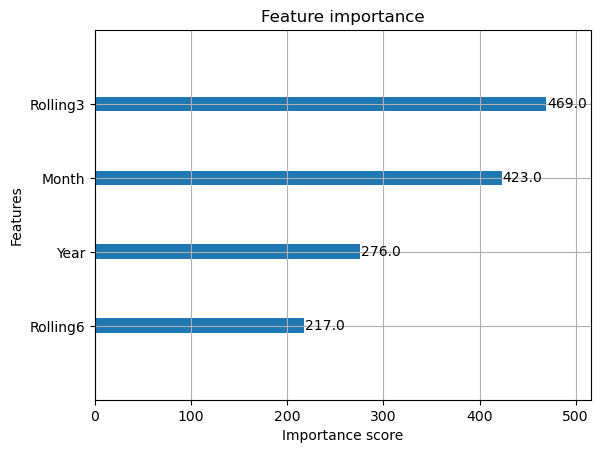

In [41]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()

In [44]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.head()

,Actual,Predicted
39,37849.2156,70754.304688
40,40677.4164,59785.828125
41,46912.8475,47876.023438
42,53942.7755,45325.429688
43,75408.7840,69165.500000


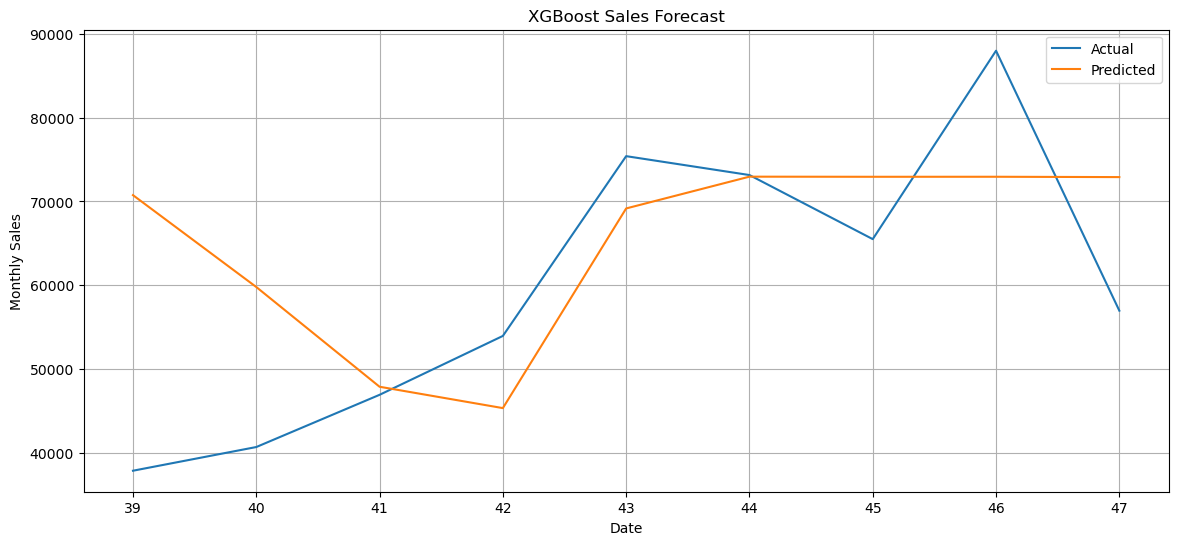

In [45]:
plt.figure(figsize=(14,6))

plt.plot(results.index, results["Actual"], label="Actual")
plt.plot(results.index, results["Predicted"], label="Predicted")

plt.title("XGBoost Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)

plt.show()

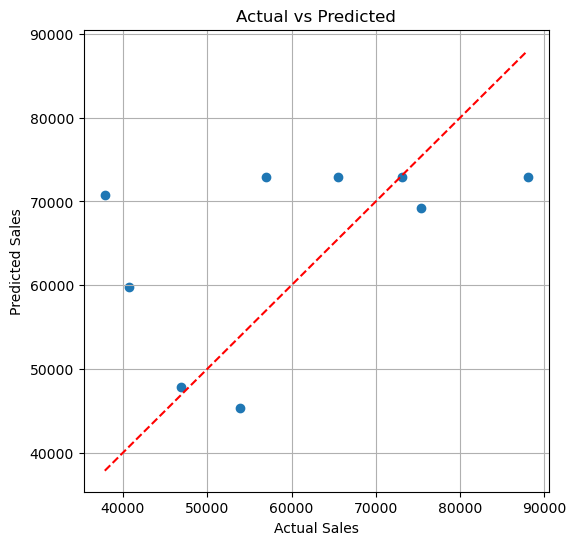

In [46]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.grid(True)

plt.show()